# PRCP-1015: Earthquake Damage Prediction Using Machine Learning

## Project Overview

Earthquakes can cause significant damage to buildings depending on factors such as building structure, construction materials, foundation type, building age, number of floors, and geographical location.

In this project, we will analyze building data collected from the region affected by the **Gorkha earthquake** and develop a Machine Learning model to predict the level of damage caused to each building.

The project mainly focuses on understanding the important factors responsible for earthquake damage, building predictive models, comparing their performance, and providing useful suggestions to reduce future earthquake-related damage.

---

# Tasks

## Task 1: Data Analysis

- Understand the dataset structure.
- Perform data cleaning and preprocessing.
- Analyze numerical and categorical features.
- Check missing and duplicate values.
- Perform Exploratory Data Analysis (EDA).
- Analyze the relationship between building features and damage grade.
- Identify important patterns and insights.

## Task 2: Predictive Model Development

- Prepare the data for Machine Learning.
- Perform feature engineering and encoding.
- Split the data into training and testing sets.
- Train multiple Machine Learning models.
- Evaluate and compare model performance.
- Select the best-performing model.
- Predict the damage grade of buildings.

## Task 3: Suggestions to Seismologists

- Identify factors responsible for severe building damage.
- Suggest improvements in construction practices.
- Recommend earthquake-resistant building structures.
- Suggest retrofitting of vulnerable buildings.
- Identify high-risk areas and building types.
- Provide recommendations for better earthquake preparedness.

---

# Target Variable

### `damage_grade`

The target variable represents the level of damage caused to a building during the earthquake.

- **1** – Low Damage
- **2** – Medium Damage
- **3** – Almost Complete Destruction

The target variable is an **ordinal variable** because the damage levels have a natural order from low to severe damage.

---

# Features

The dataset contains information related to:

- **Geographical features** – Region and location of the building.
- **Building features** – Age, number of floors, area, and height.
- **Construction features** – Foundation, roof, ground floor, position, and plan configuration.
- **Superstructure features** – Materials such as stone, brick, cement, timber, bamboo, and reinforced concrete.
- **Ownership features** – Legal ownership status.
- **Usage features** – Number of families and secondary usage of the building.

The `building_id` is a unique identifier and will not be used as a predictive feature.

---

# Project Workflow

#### 1. Project Overview
#### 2. Tasks
#### 3. Target Variable
#### 4. Features
#### 5. Import Required Libraries
#### 6. Load Dataset
#### 7. Merge Dataset
#### 8. Initial Data Inspection
#### 9. Target Variable Distribution
#### 10. Numerical Features
#### 11. Correlation Analysis
#### 12. Categorical Analysis
#### 13. Train-Test Split
#### 14. Logistic Regression
#### 15. Decision Tree
#### 16. Random Forest
#### 17. Gradient Boosting
#### 18. XGBoost
#### 19. Model Comparison
#### 20. Hyperparameter Tuning
#### 21. Feature Importance
#### 22. Recommendations

In [ ]:
# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

# Load the Dataset

In [2]:
values = pd.read_csv("train_values.csv")
labels = pd.read_csv("train_labels.csv")

In [3]:
values.head()


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels.head()

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


# Merge the Dataset

In [5]:
df = pd.merge(values,labels, on = "building_id")

In [6]:
df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


# Initial Data Inspection

## View the First Five Rows


In [7]:
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3




## Check Dataset Shape


In [8]:
df.shape

(260601, 40)



## Check Dataset Information



In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 



## Statistical Summary


In [10]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000




## Check Missing Values

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
print("Duplicate building IDs:", df["building_id"].duplicated().sum())

Duplicate building IDs: 0




## Check Duplicate Records


In [13]:
df.duplicated().sum()

np.int64(0)

In [104]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate building IDs:", df["building_id"].duplicated().sum())

Duplicate rows: 0
Duplicate building IDs: 0


# Target Variable Distribution

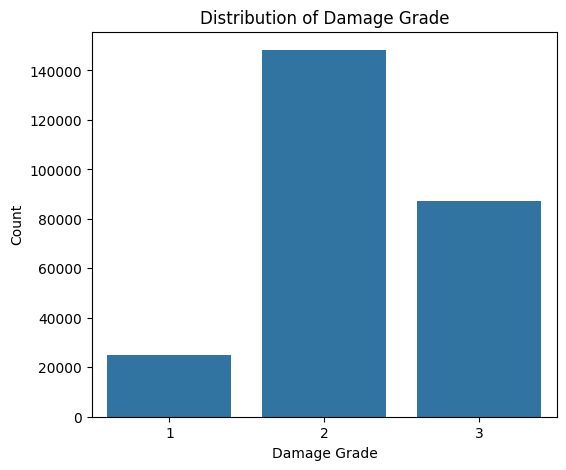

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    data = df,
    x = "damage_grade"
)
plt.title("Distribution of Damage Grade")
plt.xlabel("Damage Grade")
plt.ylabel("Count")
plt.show()

# Damage Grade Percentage Distribution

In [17]:
df["damage_grade"].value_counts(normalize=True) * 100

damage_grade
2    56.891186
3    33.468022
1     9.640792
Name: proportion, dtype: float64

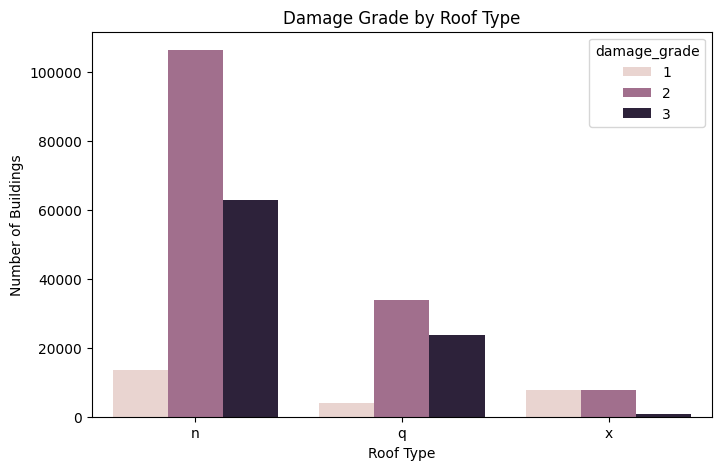

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="roof_type",
    hue="damage_grade"
)

plt.title("Damage Grade by Roof Type")
plt.xlabel("Roof Type")
plt.ylabel("Number of Buildings")
plt.show()

# Distribution of Numerical Features

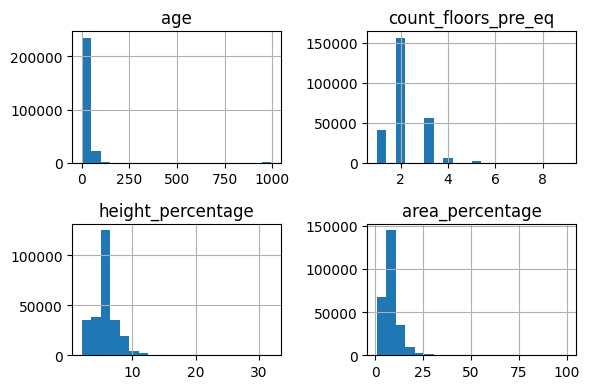

In [19]:
num_cols = [
    "age",
    "count_floors_pre_eq",
    "height_percentage",
    "area_percentage"
]

df[num_cols].hist(
    figsize=(6,4),
    bins=20
)

plt.tight_layout()
plt.show()

## Histograms

In [20]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other', 'damage_grade']


<Figure size 800x500 with 0 Axes>

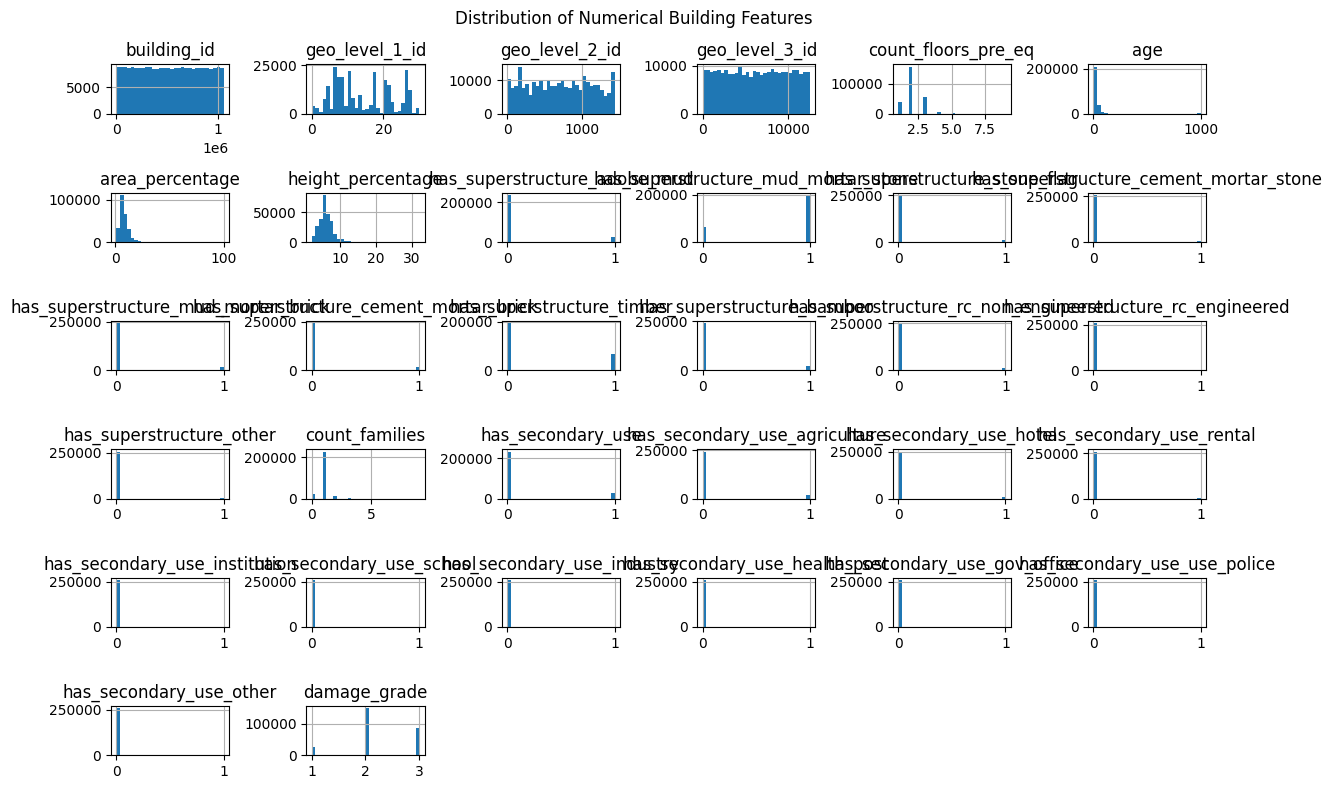

In [21]:
plt.figure(figsize=(8, 5))

df[numerical_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distribution of Numerical Building Features")
plt.tight_layout()
plt.show()

# Outlier Detection in Numerical Features



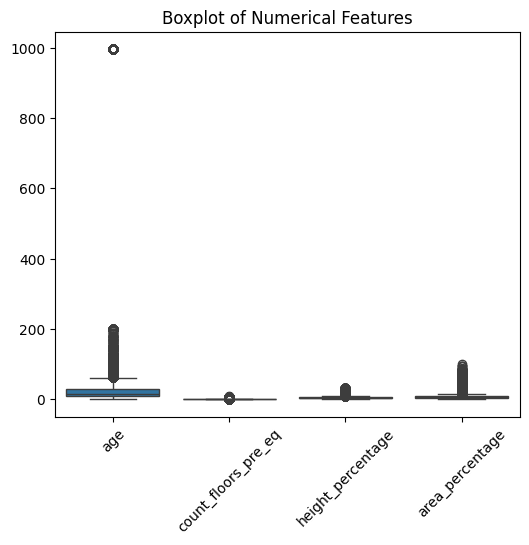

In [22]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df[
        [
            "age",
            "count_floors_pre_eq",
            "height_percentage",
            "area_percentage"
        ]
    ]
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

In [23]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other', 'damage_grade']


In [24]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} potential outliers")

building_id: 0 potential outliers
geo_level_1_id: 0 potential outliers
geo_level_2_id: 0 potential outliers
geo_level_3_id: 0 potential outliers
count_floors_pre_eq: 103978 potential outliers
age: 12499 potential outliers
area_percentage: 13557 potential outliers
height_percentage: 7843 potential outliers
has_superstructure_adobe_mud: 23101 potential outliers
has_superstructure_mud_mortar_stone: 62040 potential outliers
has_superstructure_stone_flag: 8947 potential outliers
has_superstructure_cement_mortar_stone: 4752 potential outliers
has_superstructure_mud_mortar_brick: 17761 potential outliers
has_superstructure_cement_mortar_brick: 19615 potential outliers
has_superstructure_timber: 0 potential outliers
has_superstructure_bamboo: 22154 potential outliers
has_superstructure_rc_non_engineered: 11099 potential outliers
has_superstructure_rc_engineered: 4133 potential outliers
has_superstructure_other: 3905 potential outliers
count_families: 34486 potential outliers
has_secondary_use:

In [25]:
## Correlation matrix

In [26]:
corr_cols = [
    "damage_grade",
    "age",
    "count_floors_pre_eq",
    "height_percentage",
    "area_percentage"
]

corr_matrix = df[corr_cols].corr()

print(corr_matrix)

                     damage_grade       age  count_floors_pre_eq  \
damage_grade             1.000000  0.029273             0.122308   
age                      0.029273  1.000000             0.086668   
count_floors_pre_eq      0.122308  0.086668             1.000000   
height_percentage        0.048130  0.061074             0.772734   
area_percentage         -0.125221 -0.004323             0.101071   

                     height_percentage  area_percentage  
damage_grade                  0.048130        -0.125221  
age                           0.061074        -0.004323  
count_floors_pre_eq           0.772734         0.101071  
height_percentage             1.000000         0.196645  
area_percentage               0.196645         1.000000  



## Correlation Heatmap

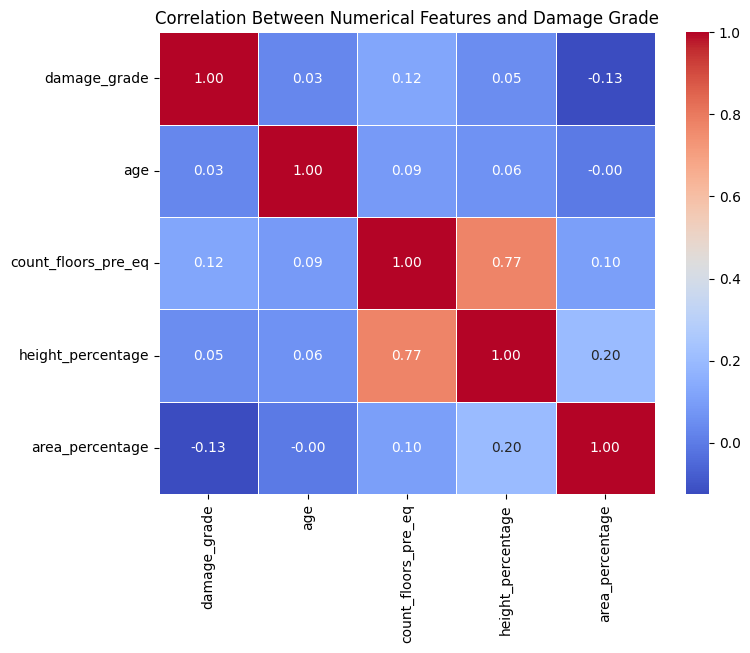

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features and Damage Grade")
plt.show()

In [29]:
## Damage-grade correlation ranking

In [30]:
damage_corr = (
    corr_matrix["damage_grade"]
    .drop("damage_grade")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Damage Grade:")
print(damage_corr)

Correlation with Damage Grade:
area_percentage       -0.125221
count_floors_pre_eq    0.122308
height_percentage      0.048130
age                    0.029273
Name: damage_grade, dtype: float64


### Observation

The correlation analysis examines the relationship between numerical building characteristics and earthquake damage grade. The results show the direction and strength of linear relationships between the numerical features and damage grade. However, correlation does not imply causation, and model-based feature importance is used later to identify the most important predictive features.

## Categorical Feature Analysis

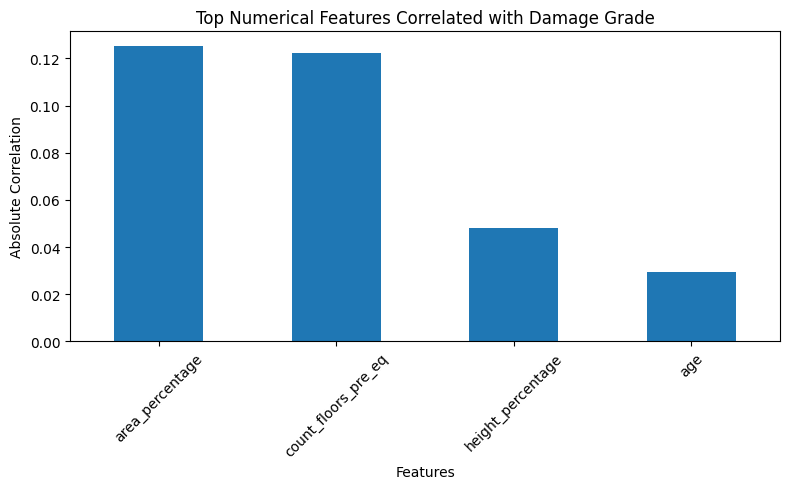

In [31]:
damage_corr = (
    corr_matrix["damage_grade"]
    .drop("damage_grade")
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

damage_corr.head(10).plot(kind="bar")

plt.title("Top Numerical Features Correlated with Damage Grade")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

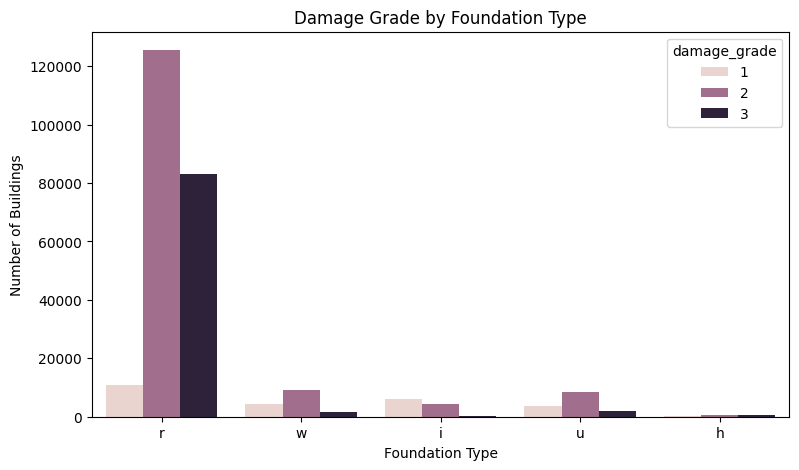

In [32]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="foundation_type",
    hue="damage_grade"
)

plt.title("Damage Grade by Foundation Type")
plt.xlabel("Foundation Type")
plt.ylabel("Number of Buildings")

plt.show()

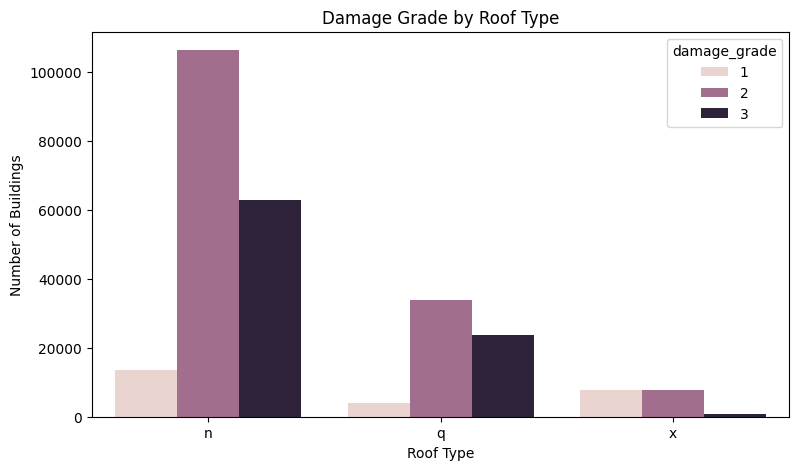

In [33]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="roof_type",
    hue="damage_grade"
)

plt.title("Damage Grade by Roof Type")
plt.xlabel("Roof Type")
plt.ylabel("Number of Buildings")

plt.show()

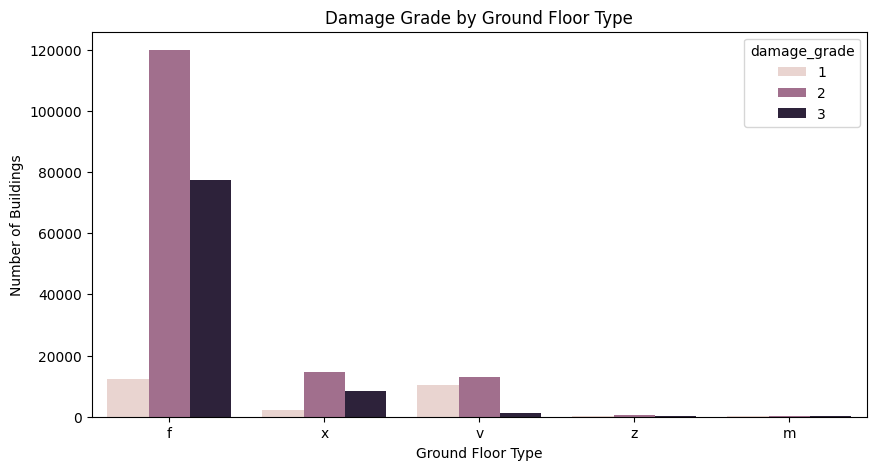

In [34]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="ground_floor_type",
    hue="damage_grade"
)

plt.title("Damage Grade by Ground Floor Type")
plt.xlabel("Ground Floor Type")
plt.ylabel("Number of Buildings")

plt.show()

### Observation

The categorical analysis shows that the distribution of earthquake damage grades differs across several building characteristics. Foundation type, roof type, and ground-floor type show different damage-grade distributions across their categories. These differences indicate that construction-related categorical variables may be associated with earthquake damage and may provide useful information for predicting damage grade.

In [35]:
df.dtypes.value_counts()

int64     32
object     8
Name: count, dtype: int64

In [36]:
df.select_dtypes(include="object").columns

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='object')

In [37]:
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

In [38]:
df.dtypes.value_counts()

int64    62
Name: count, dtype: int64

In [39]:
df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,6,487,12198,2,30,6,5,1,1,...,0,0,0,0,0,0,0,0,1,0
1,28830,8,900,2812,2,10,8,7,0,1,...,0,0,0,0,0,0,0,0,1,0
2,94947,21,363,8973,2,10,5,5,0,1,...,0,0,0,0,0,0,0,0,1,0
3,590882,22,418,10694,2,10,6,5,0,1,...,0,0,0,0,0,0,0,0,1,0
4,201944,11,131,1488,3,30,8,9,1,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,0,1,...,0,0,0,0,1,0,0,0,1,0
260597,669485,17,715,2060,2,0,6,5,0,1,...,0,0,0,0,0,0,0,0,1,0
260598,602512,17,51,8163,3,55,6,7,0,1,...,0,0,0,0,0,0,0,0,1,0
260599,151409,26,39,1851,2,10,14,6,0,0,...,0,0,0,0,0,0,0,0,1,0


# Train-Test Split and Feature Scaling

The dataset is divided into training and testing sets using an 80:20 ratio.

Feature scaling is performed using **StandardScaler** so that numerical features are brought to a common scale. The scaler is fitted only on the training data and then applied to both training and testing data to avoid data leakage.



In [40]:
# Separate features and target

X = df.drop(columns=["damage_grade", "building_id"])
y = df["damage_grade"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (260601, 60)
Target shape: (260601,)


In [41]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
[]


In [42]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other', 'land_surface_condition_o', 'land_surface_condition_t', 'foundation_type_i', 'foundation_type_r', 'foundation_type_u', 'found

In [43]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X.shape)

Shape after encoding: (260601, 60)


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (208480, 60)
Testing shape: (52121, 60)


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


# Logistic Regression



In [46]:
from sklearn.linear_model import LogisticRegression

Lo_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Lo_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
Lo_Pred = Lo_model.predict(X_test_scaled)

print(Lo_Pred)

[3 2 2 ... 2 2 2]


In [48]:
Lo_accuracy = accuracy_score(y_test, Lo_Pred)
print("Accuracy :", Lo_accuracy)

Lo_precision = precision_score(y_test, Lo_Pred, average="weighted")
print("Precision :", Lo_precision)

Lo_recall = recall_score(y_test, Lo_Pred, average="weighted")
print("Recall :", Lo_recall)

Lo_f1 = f1_score(y_test, Lo_Pred, average="weighted")
print("F1 Score :", Lo_f1)

Accuracy : 0.5919303159954721
Precision : 0.5802943299638037
Recall : 0.5919303159954721
F1 Score : 0.5397309089577103




### Observation

Logistic Regression achieved an accuracy of **59.19%** and an F1 Score of **53.97%**. It provides a basic baseline model but struggles to distinguish between the three damage grades effectively.

In [49]:
cr = classification_report(y_test, Lo_Pred)

print("Classification Report:")
print(cr)

Classification Report:
              precision    recall  f1-score   support

           1       0.56      0.29      0.38      5025
           2       0.60      0.87      0.71     29652
           3       0.55      0.20      0.29     17444

    accuracy                           0.59     52121
   macro avg       0.57      0.46      0.46     52121
weighted avg       0.58      0.59      0.54     52121



# Confusion Matrix - Logistic Regression



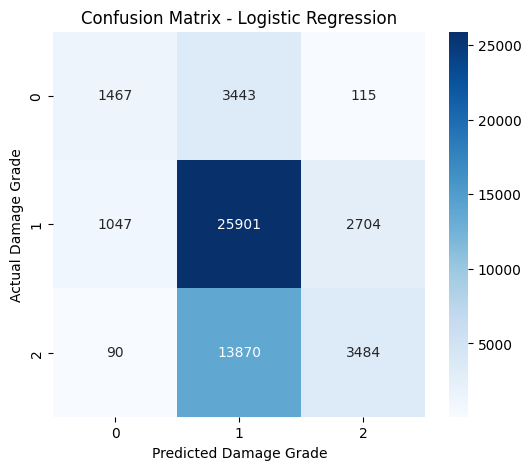

In [50]:
cm = confusion_matrix(y_test, Lo_Pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Damage Grade")
plt.ylabel("Actual Damage Grade")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Observation

The confusion matrix shows that the Logistic Regression model predicts **Damage Grade 2** more accurately than Grades 1 and 3. A considerable number of Grade 1 and Grade 3 buildings are incorrectly predicted as Grade 2, indicating that the model has difficulty distinguishing between the different damage levels.

# Decision Tree Classifier



In [51]:
from sklearn.tree import DecisionTreeClassifier
Dc_model = DecisionTreeClassifier(
    random_state=42
)
Dc_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
Dc_Pred = Dc_model.predict(X_test)
Dc_Pred


array([2, 2, 3, ..., 3, 2, 2], shape=(52121,))

In [53]:
Dc_accuracy = accuracy_score(y_test, Dc_Pred)
print("Accuracy :", Dc_accuracy)

Dc_precision = precision_score(y_test, Dc_Pred, average="weighted")
print("Precision :", Dc_precision)

Dc_recall = recall_score(y_test, Dc_Pred, average="weighted")
print("Recall :", Dc_recall)

Dc_f1 = f1_score(y_test, Dc_Pred, average="weighted")
print("F1 Score :", Dc_f1)

Accuracy : 0.6589858214539245
Precision : 0.6602397468070087
Recall : 0.6589858214539245
F1 Score : 0.6595698621756082


### Observation

Decision Tree achieved an accuracy of **65.89%** and an F1 Score of **65.95%**. It performed better than Logistic Regression by capturing non-linear relationships in the building features.

In [54]:
cr = classification_report(y_test, Dc_Pred)
print("Classification Report :")
print(cr)

Classification Report :
              precision    recall  f1-score   support

           1       0.49      0.51      0.50      5025
           2       0.71      0.71      0.71     29652
           3       0.62      0.62      0.62     17444

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121



# Confusion Matrix - Decision Tree



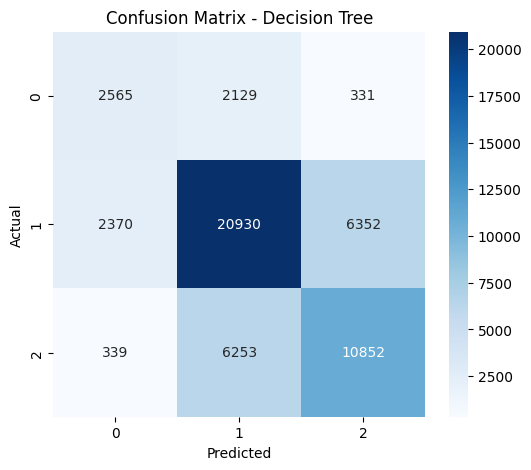

In [55]:
cm = confusion_matrix(y_test, Dc_Pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Decision Tree")

plt.show()


The confusion matrix shows that the Decision Tree model correctly classifies a good number of buildings across all three damage grades. Most misclassifications occur between **Damage Grade 2 and Damage Grade 3**, while Damage Grade 1 is comparatively more difficult to classify.

# Random Forest Classifier


In [56]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
Rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees
    random_state=42        # Ensures reproducible results
)

# Train the model
Rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
Rf_Pred = Rf_model.predict(X_test)
Rf_Pred

array([2, 2, 2, ..., 2, 2, 2], shape=(52121,))

In [58]:
Rf_accuracy = accuracy_score(y_test, Rf_Pred)
print("Accuracy :", Rf_accuracy)

Rf_precision = precision_score(y_test, Rf_Pred, average="weighted")
print("Precision :", Rf_precision)

Rf_recall = recall_score(y_test, Rf_Pred, average="weighted")
print("Recall :", Rf_recall)

Rf_f1 = f1_score(y_test, Rf_Pred, average="weighted")
print("F1 Score :", Rf_f1)

Accuracy : 0.7169662899790872
Precision : 0.714859098107937
Recall : 0.7169662899790872
F1 Score : 0.7109208592207782




### Observation

Random Forest achieved an accuracy of **71.69%** and an F1 Score of **71.09%**. It performed better than Logistic Regression and Decision Tree, providing more balanced predictions across the damage grades.

In [59]:
cr = classification_report(y_test, Rf_Pred)

print("Classification Report :")
print(cr)

Classification Report :
              precision    recall  f1-score   support

           1       0.65      0.48      0.55      5025
           2       0.72      0.83      0.77     29652
           3       0.72      0.60      0.65     17444

    accuracy                           0.72     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.71      0.72      0.71     52121



# Confusion Matrix - Random Forest



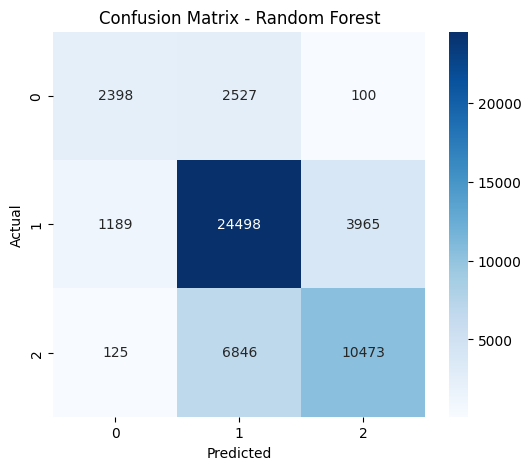

In [60]:
cm = confusion_matrix(y_test, Rf_Pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.show()



### Observation

The confusion matrix shows that the Random Forest model provides better classification across all three damage grades compared with the previous models. Most predictions are correctly classified, with the majority of misclassifications occurring between **Damage Grade 2 and Damage Grade 3**.

# Gradient Boosting Classifier


In [61]:
from sklearn.ensemble import  GradientBoostingClassifier

Gb_model = GradientBoostingClassifier(
    random_state=42
)

Gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [62]:
Gb_Pred = Gb_model.predict(X_test)
Gb_Pred

array([2, 2, 2, ..., 2, 2, 2], shape=(52121,))

In [63]:
Gb_accuracy = accuracy_score(y_test, Gb_Pred)
print("Accuracy :", Gb_accuracy)

Gb_precision = precision_score(y_test, Gb_Pred, average="weighted")
print("Precision :", Gb_precision)

Gb_recall = recall_score(y_test, Gb_Pred, average="weighted")
print("Recall :", Gb_recall)

Gb_f1 = f1_score(y_test, Gb_Pred, average="weighted")
print("F1 Score :", Gb_f1)

Accuracy : 0.6817981235970146
Precision : 0.6858459220870974
Recall : 0.6817981235970146
F1 Score : 0.6649701266574146


### Observation

The Gradient Boosting model achieved an **Accuracy of 68.18%**, **Precision of 68.58%**, **Recall of 68.18%**, and **F1 Score of 66.50%**. The results indicate that the model provides moderate classification performance in predicting earthquake building damage grades.


In [64]:
cr = classification_report(y_test, Gb_Pred)

print("Classification Report :")
print(cr)

Classification Report :
              precision    recall  f1-score   support

           1       0.64      0.38      0.47      5025
           2       0.67      0.86      0.76     29652
           3       0.72      0.47      0.57     17444

    accuracy                           0.68     52121
   macro avg       0.68      0.57      0.60     52121
weighted avg       0.69      0.68      0.66     52121



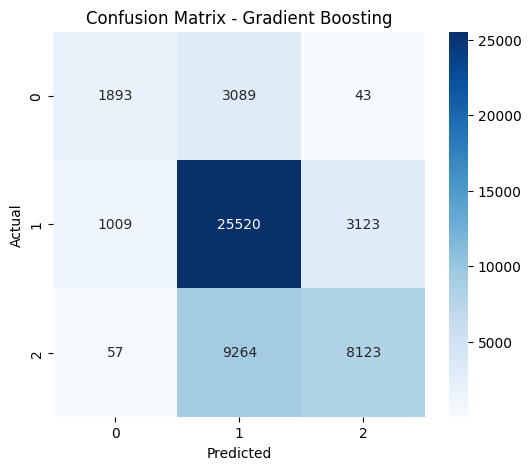

In [65]:
cm = confusion_matrix(y_test, Gb_Pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

# XGBoost Classifier

In [66]:
print(df.shape)
print(df.head())

(260601, 62)
   building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0       802906               6             487           12198   
1        28830               8             900            2812   
2        94947              21             363            8973   
3       590882              22             418           10694   
4       201944              11             131            1488   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    2   30                6                  5   
1                    2   10                8                  7   
2                    2   10                5                  5   
3                    2   10                6                  5   
4                    3   30                8                  9   

   has_superstructure_adobe_mud  has_superstructure_mud_mortar_stone  ...  \
0                             1                                    1  ...   
1                             0  

In [67]:
y_xgb = df["damage_grade"] - 1

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

In [68]:
# XGBoost requires class labels starting from 0

X_train_xgb = X_train
X_test_xgb = X_test

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

print("XGBoost training classes:", sorted(y_train_xgb.unique()))
print("XGBoost testing classes:", sorted(y_test_xgb.unique()))

XGBoost training classes: [np.int64(0), np.int64(1), np.int64(2)]
XGBoost testing classes: [np.int64(0), np.int64(1), np.int64(2)]


In [69]:
from xgboost import XGBClassifier

Xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

Xgb_model.fit(X_train_xgb, y_train_xgb)

Xgb_Pred = Xgb_model.predict(X_test_xgb)

Xgb_Pred


array([1, 1, 0, ..., 1, 1, 1], shape=(52121,))

In [70]:
print("X_train_xgb:", X_train_xgb.shape)
print("X_test_xgb:", X_test_xgb.shape)
print("y_train_xgb:", y_train_xgb.shape)
print("y_test_xgb:", y_test_xgb.shape)

X_train_xgb: (208480, 60)
X_test_xgb: (52121, 60)
y_train_xgb: (208480,)
y_test_xgb: (52121,)


In [71]:
Xgb_accuracy = accuracy_score(y_test_xgb, Xgb_Pred)
print("Accuracy :", Xgb_accuracy)

Xgb_precision = precision_score( y_test_xgb, Xgb_Pred, average="weighted")
print("Precision :", Xgb_precision)

Xgb_recall = recall_score(y_test_xgb, Xgb_Pred, average="weighted")
print("Recall :", Xgb_recall)

Xgb_f1 = f1_score(y_test_xgb, Xgb_Pred, average="weighted")
print("F1 Score :", Xgb_f1)

Accuracy : 0.7289384317261757
Precision : 0.7295267119932455
Recall : 0.7289384317261757
F1 Score : 0.7212577741171208


### Observation

The XGBoost model achieved the highest overall performance among the evaluated models, with an **Accuracy of 72.89%**, **Precision of 72.95%**, **Recall of 72.89%**, and **F1 Score of 72.13%**. These results indicate that XGBoost provides strong classification performance for predicting earthquake building damage grades.


In [72]:
cr = classification_report(y_test_xgb, Xgb_Pred)

print("Classification Report :")
print(cr)


Classification Report :
              precision    recall  f1-score   support

           0       0.68      0.46      0.55      5025
           1       0.72      0.85      0.78     29652
           2       0.75      0.60      0.66     17444

    accuracy                           0.73     52121
   macro avg       0.72      0.64      0.67     52121
weighted avg       0.73      0.73      0.72     52121



# Confusion Matrix - XGBoost

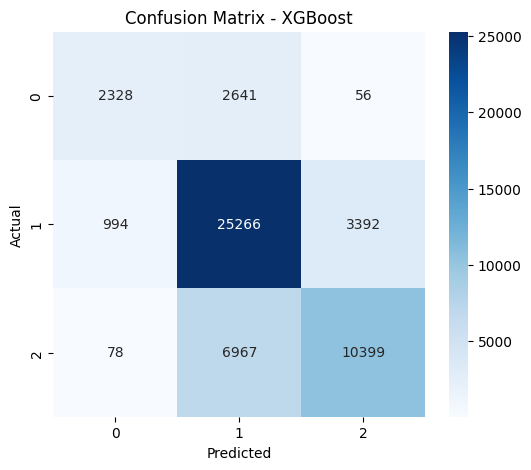

In [73]:
cm = confusion_matrix(y_test_xgb, Xgb_Pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

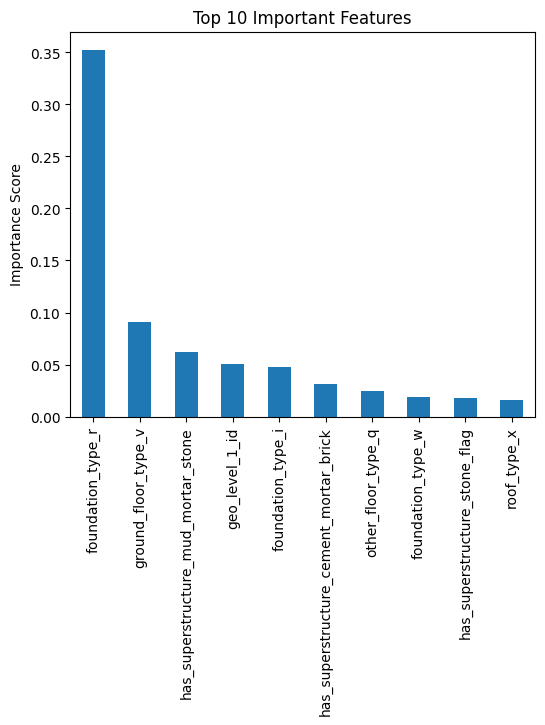

In [74]:
feature_importance = pd.Series(
    Xgb_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()


# Model Comparison

### Observation

The performance of all trained models was compared using Accuracy, Precision, Recall, and F1 Score. The model with the best overall performance will be selected as the final model for earthquake damage prediction.

In [75]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        Lo_accuracy,
        Dc_accuracy,
        Rf_accuracy,
        Gb_accuracy,
        Xgb_accuracy
    ],

    "Precision": [
        Lo_precision,
        Dc_precision,
        Rf_precision,
        Gb_precision,
        Xgb_precision
    ],

    "Recall": [
        Lo_recall,
        Dc_recall,
        Rf_recall,
        Gb_recall,
        Xgb_recall
    ],

    "F1 Score": [
        Lo_f1,
        Dc_f1,
        Rf_f1,
        Gb_f1,
        Xgb_f1
    ]
})

comparison = (
    comparison
    .sort_values(by="Accuracy", ascending=False)
    .round(4)
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.7289,0.7295,0.7289,0.7213
2,Random Forest,0.7170,0.7149,0.7170,0.7109
3,Gradient Boosting,0.6818,0.6858,0.6818,0.6650
1,Decision Tree,0.6590,0.6602,0.6590,0.6596
0,Logistic Regression,0.5919,0.5803,0.5919,0.5397


### Observation

The model comparison shows that **XGBoost achieved the highest overall performance**, with an Accuracy of **72.89%** and an F1 Score of **72.13%**. Random Forest was the second-best model, achieving **71.70% Accuracy** and **71.09% F1 Score**. Gradient Boosting and Decision Tree showed moderate performance, while Logistic Regression achieved the lowest performance with **59.19% Accuracy** and **53.97% F1 Score**. Overall, XGBoost performed best among the evaluated models based on Accuracy and F1 Score.


# Model Accuracy Comparison

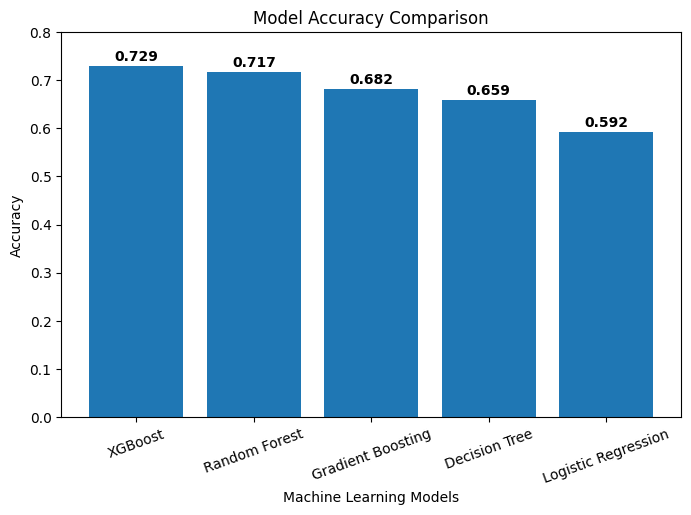

In [76]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,          
        f"{height:.3f}",         
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 0.8)

plt.show()


# XGBoost Hyperparameter Tuning

In [95]:


from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [100],
    "max_depth": [3, 5],
    "learning_rate": [0.1],
    "subsample": [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_xgb, y_train_xgb)

print("Best Parameters:")
print(grid.best_params_)

print(f"Best CV Accuracy: {grid.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV Accuracy: 69.52%


# Final Tuned XGBoost Model

In [96]:
best_xgb = grid.best_estimator_

best_pred = best_xgb.predict(X_test_xgb)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Final Tuned XGBoost Performance")
print("--------------------------------")

print(f"Accuracy  : {accuracy_score(y_test_xgb, best_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test_xgb, best_pred, average='weighted', zero_division=0) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test_xgb, best_pred, average='weighted', zero_division=0) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test_xgb, best_pred, average='weighted', zero_division=0) * 100:.2f}%")

Final Tuned XGBoost Performance
--------------------------------
Accuracy  : 69.67%
Precision : 69.88%
Recall    : 69.67%
F1 Score  : 68.39%


# Feature Importance Analysis

In [102]:


import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
foundation_type_r                         0.426281
ground_floor_type_v                       0.087222
has_superstructure_mud_mortar_stone       0.063302
geo_level_1_id                            0.039152
foundation_type_i                         0.037044
has_superstructure_cement_mortar_brick    0.036201
other_floor_type_q                        0.026235
age                                       0.017652
foundation_type_w                         0.016305
has_superstructure_mud_mortar_brick       0.015998
dtype: float32


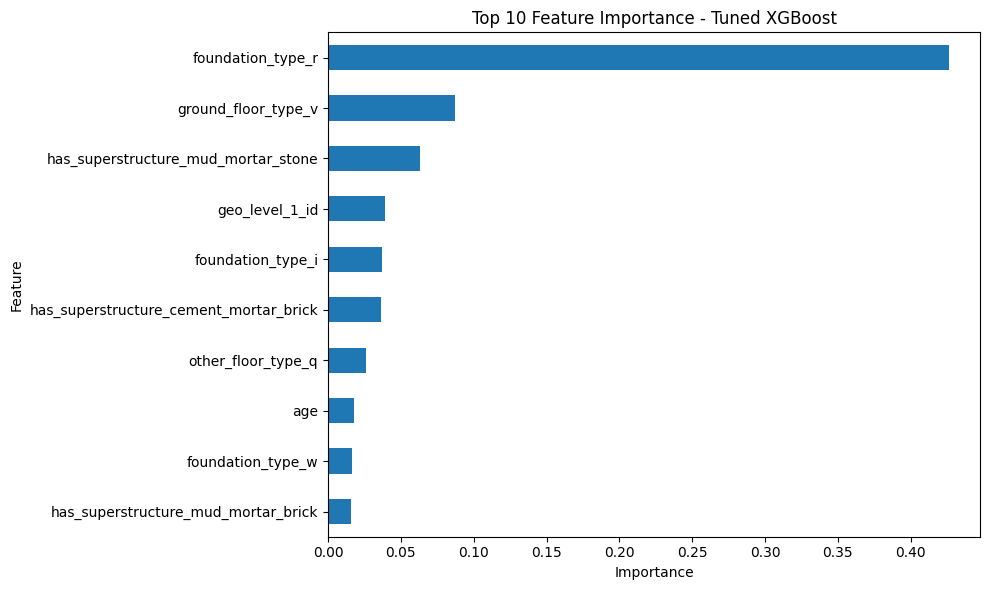

In [103]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Observation

The feature importance analysis identifies the building characteristics
that contributed most to the predictions made by the tuned XGBoost model.
The most important features can be considered key predictive factors
for earthquake building damage classification. However, feature
importance indicates predictive contribution and should not be interpreted
as direct causal evidence.

## Save Pickle File

In [100]:
import joblib

joblib.dump(best_xgb, "earthquake_damage_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Pickle load test

In [101]:
loaded_model = joblib.load("earthquake_damage_xgboost_model.pkl")

loaded_pred = loaded_model.predict(X_test_xgb)

print("Loaded model accuracy:",
      accuracy_score(y_test_xgb, loaded_pred) * 100)

Loaded model accuracy: 69.66865562824965


# Recommendations

Based on the analysis and machine learning results:

- Buildings should be designed and constructed according to appropriate earthquake-resistant building standards.
- Vulnerable building characteristics identified by the model can be prioritized during structural safety assessments.
- Older and structurally vulnerable buildings should receive greater attention during earthquake preparedness programs.
- Foundation, roof, wall, and structural characteristics should be considered when assessing building vulnerability.
- The model can be used as a supporting tool for identifying buildings that may require further structural assessment.

# Future Scope

* The model can be improved by testing additional machine learning and deep learning algorithms.
* Larger and more diverse earthquake and building datasets can be used to improve model generalization.
* Hyperparameter optimization techniques such as RandomizedSearchCV or Bayesian Optimization can be explored for better model performance.
* Additional structural, geographical, and environmental features can be incorporated to improve earthquake damage prediction.
* The trained model can be integrated into a web or mobile application for practical earthquake risk assessment.
* Explainable AI techniques can be used to provide clearer explanations of why a building is predicted to belong to a particular damage grade.
* The system can be extended to support real-time earthquake data and assist in rapid post-earthquake building vulnerability assessment.


# Conclusion

This project developed a machine learning approach for predicting earthquake building damage using structural, construction, and geographical features.

Several classification models were trained and evaluated using Accuracy, Precision, Recall, and F1 Score. XGBoost was further optimized using GridSearchCV with 5-fold cross-validation. The best hyperparameters were `learning_rate = 0.1`, `max_depth = 5`, `n_estimators = 100`, and `subsample = 0.8`.

The tuned XGBoost model achieved a cross-validation accuracy of **69.52%** and a test accuracy of **69.67%**, with a weighted Precision of **69.88%**, Recall of **69.67%**, and F1 Score of **68.39%**.

The feature importance analysis helped identify the building characteristics that contributed most to the model's predictions. These findings can support the understanding of building vulnerability and may assist in earthquake-risk assessment and preparedness planning.

Although the tuned model did not outperform the previously evaluated untuned XGBoost model on the test dataset, the hyperparameter tuning process provided a systematic method for selecting model parameters using cross-validation.

Overall, the project demonstrates that machine learning can be used to identify patterns associated with earthquake building damage and can serve as a supporting tool for building vulnerability analysis and earthquake-resilience planning.
